In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
import seaborn as sn
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


In [2]:
# Load the data
train_in = pd.read_csv("data/train_in.csv", header = None)
train_out = pd.read_csv("data/train_out.csv", header = None)
test_in = pd.read_csv("data/test_in.csv", header = None)
test_out = pd.read_csv("data/test_out.csv", header = None)

### Task 1

#### 1.1 head in the clouds

In [3]:
# Calculate mean for each digit d over all training images
cloud_means = {}
for d in range(0, 10):
    # Select images belonging to this digit
    mask = (np.array(train_out[0]) == d)
    cloud = train_in[mask]
    
    # Calculate colmeans
    cloud_means[d] = cloud.mean(axis = 0)

In [4]:
# Classify new images
prediction = [np.nan] * test_in.shape[0]
for i in range(test_in.shape[0]):
    # Calculate distance to each center
    dist = {}

    # Probably could use numpy magic here but couldn't bother since the LIACS PCs have crazy specs anyway
    for d in range(0, 10):
        dist[d] = np.sum(np.abs(test_in.iloc[i] - cloud_means[d])) 

    prediction[i] = min(dist, key = dist.get)



In [5]:
# Look at the misclassification
prediction = np.array(prediction)
y_test = test_out.iloc[:, 0].to_numpy()
misclassifications = np.sum(prediction != y_test) 
print(f"{misclassifications} misclassifications")

279 misclassifications


In [6]:
# Distance matrix
distance_matrix = np.zeros((10, 10))

centers = np.array([cloud_means[d] for d in range(10)])

for i in range(10):
    for j in range(10):
        distance_matrix[i, j] = np.sum(np.abs(centers[i] - centers[j]))

print(distance_matrix)

[[  0.         182.59114732 120.26890998 108.48295121 131.65671648
   90.29690321  96.58295761 148.68251439 119.05778964 138.00987252]
 [182.59114732   0.         128.6340838  135.65583112 116.75278799
  137.42571735 116.44754023 109.58280622 114.1412629   99.15015404]
 [120.26890998 128.6340838    0.          99.03464322  99.9930043
   95.36867113  87.25538768 108.76652344  84.61392774 112.3774649 ]
 [108.48295121 135.65583112  99.03464322   0.         108.38826092
   67.95490016 107.83862166 102.55046137  76.75056038  90.36976671]
 [131.65671648 116.75278799  99.9930043  108.38826092   0.
   97.87365779 104.13659592  89.66743028  81.69990745  62.74497963]
 [ 90.29690321 137.42571735  95.36867113  67.95490016  97.87365779
    0.          77.34411732 112.33280873  85.33166856  95.70081439]
 [ 96.58295761 116.44754023  87.25538768 107.83862166 104.13659592
   77.34411732   0.         135.80282107  99.3984983  125.23637508]
 [148.68251439 109.58280622 108.76652344 102.55046137  89.667430

No idea what they mean with the expected accuracy of the classifier but it's a bit suspicious that I got 0 misclassifications. To see what pair of digits are most difficult to separate we look at the distance matrix, and see that the pair with the smallest distance is. From our results, we see that the pair with the smallest distance is 7-9

#### 1.2

PCA: https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-with-python/

In [7]:
pca = PCA(n_components = 2) 
y_train = np.array(train_out).ravel()
y_test = np.array(test_out).ravel()

# Apply PCA function
X_train = pca.fit_transform(train_in)
X_test = pca.fit_transform(test_in)

# Fit LR to training set
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predict test set result
y_pred = classifier.predict(X_test)

/home/s3704653/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


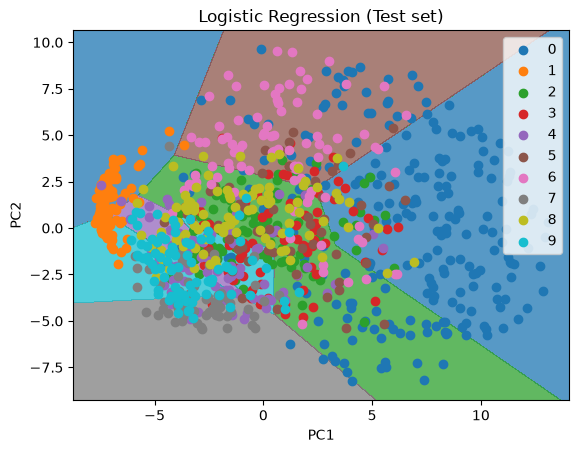

In [8]:
# Visualising the Test set results through scatter plot
X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1,
                               stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1,
                               stop=X_set[:, 1].max() + 1, step=0.01))

# What the classifier predicts
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(),
                                                  X2.ravel()]).T).reshape(X1.shape), alpha=0.75,
             cmap=plt.cm.tab10)

# Plot actual values in the train set
for i, j in enumerate(np.unique(y_test)):
    plt.scatter(X_test[y_test == j, 0], X_test[y_test == j, 1],
                color=plt.cm.tab10(i), label=j)

plt.title('Logistic Regression (Test set)')
plt.xlabel('PC1')  
plt.ylabel('PC2')  
plt.legend()

plt.show()

UMAP https://www.geeksforgeeks.org/machine-learning/umap-uniform-manifold-approximation-and-projection/

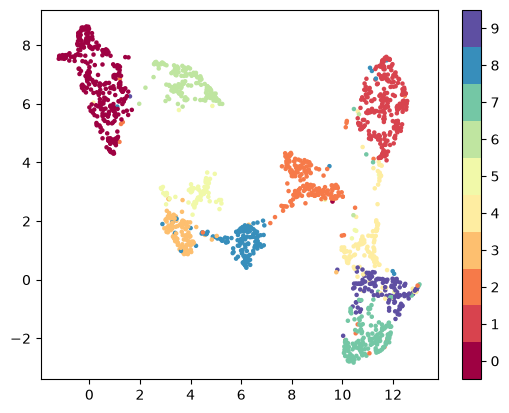

In [9]:
data = train_in
labels = train_out.iloc[:, 0].to_numpy()

# Apply UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(data)
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=5)
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.show()

t-SNE https://www.geeksforgeeks.org/machine-learning/ml-t-distributed-stochastic-neighbor-embedding-t-sne-algorithm/

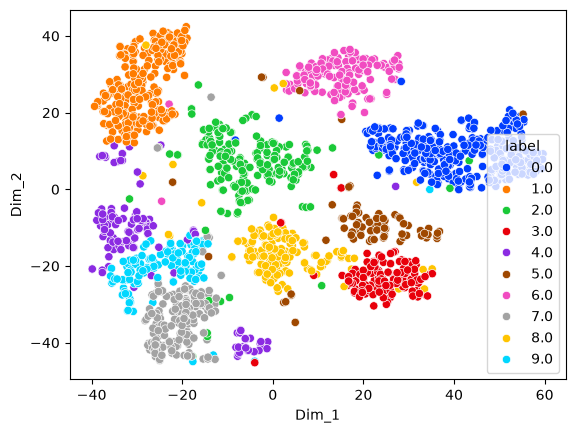

In [10]:
model = TSNE(n_components = 2, random_state = 0)

tsne_data = model.fit_transform(data)
tsne_data = np.vstack((tsne_data.T, labels)).T
tsne_df = pd.DataFrame(data = tsne_data,
     columns =("Dim_1", "Dim_2", "label"))

sn.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2',
               hue='label', palette="bright")
plt.show()


Broskis I have no clue what's happening here, but I guess the visualisations agree with our intuitions earlier that 7 and 9 are the closest pair (distance-wise), since they seem to be near eachother in each of the plots

#### 1.3



In [11]:
# Classify new images
def classifications(set_in, set_out, set_name = ""):
    """
    Calculate the amount of correctly classified digits 
    """
    set_pred = [np.nan] * set_in.shape[0]

    for i in range(set_in.shape[0]):
        dist = {}

        for d in range(0, 10):
            dist[d] = np.sum(np.abs(set_in.iloc[i] - cloud_means[d]))

        set_pred[i] = min(dist, key = dist.get)

    set_pred = np.array(set_pred)
    y_set = set_out.iloc[:, 0].to_numpy()

    correct_class = np.sum(set_pred == y_set)
    print(f"{correct_class/len(set_pred):.2f}% correctly classified digits for the {set_name}")

classifications(train_in, train_out, "train set")
classifications(test_in, test_out, "test set")

0.77% correctly classified digits for the train set
0.72% correctly classified digits for the test set


##### 1.4

https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/

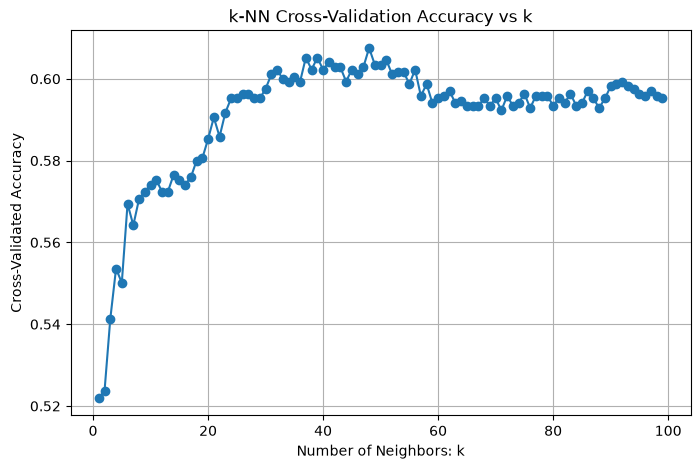

Best k from cross-validation: 48


In [12]:
# Train kNN classifier
k_range = range(1, 100)
cv_scores = [] # Store cross-validation scores here

# Evaluate each k, using 10-fold CV
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    scores = cross_val_score(knn, X_train, y_train, cv = 10, scoring = "accuracy")
    cv_scores.append(scores.mean())

# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()

# Best k
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")


In [13]:
# Train model on test set with best k 
best_knn = KNeighborsClassifier(n_neighbors=48)
best_knn.fit(X_train, y_train)

# Predict on test data
y_pred_train = best_knn.predict(X_train)
y_pred_test = best_knn.predict(X_test)
print(f"{np.mean(y_pred_train == y_train):.3f}% accuracy on the train set")
print(f"{np.mean(y_pred_test == y_test):.3f}% accuracy on the test set")

0.628% accuracy on the train set
0.428% accuracy on the test set


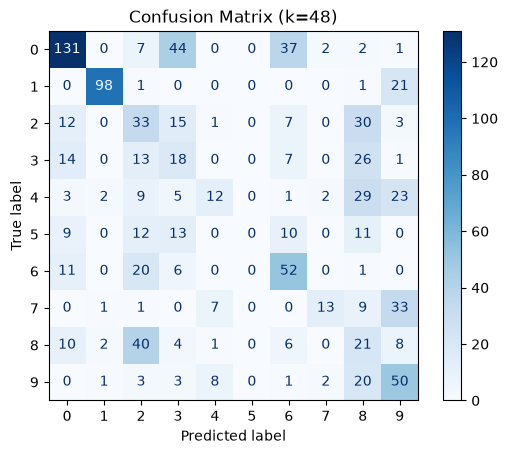

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k={best_k})")
plt.grid(False)
plt.show()

We see that our model is good at predicting "0" and "1" and really bad at predicting something as "5" (it actually doesn't predict anything as 5).

### Task 2

Notes
* We have 10 independent classifiers
* Each classifier has its own weights (256 weights, one for each pixel)
* Putting this in a 10 x 256 matrix 
    * Each row x represents the weights used to recognise digit x
    * We also want to include the bias in the matrix, so it becomes a 10 x 257 matrix

In [52]:
# Set up parameters
n_pixel = 256
n_digit = 10 

# Append column representing bias to the train and test data
X_train = np.column_stack([train_in, np.ones(len(train_in))])
X_test = np.column_stack([test_in, np.ones(len(test_in))])

# Implement multi-class perceptron training algorithm
def perceptron_alg(X_set, y_set, epochs = 100, learning_rate = 0.01):

    W = np.random.rand(n_digit, n_pixel + 1) # Initialise random weights

    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)

    for i in range(epochs):
        # Calculate scores
        scores = X_set @ W.T 

        # Make predictions
        predictions = np.argmax(scores, axis = 1)
        train_acc[i] = np.mean(predictions == y_set)

        # Get the wrong predictions
        mask_wrong = (predictions != y_set)
        X_wrong = X_set[mask_wrong]
        y_wrong = y_set[mask_wrong]
        pred_wrong = predictions[mask_wrong]

        # NOTE (see below)
        # Update matrix: +1 for the true class, and -1 for wrong predictions 
        update_matrix = np.zeros((len(X_wrong), n_digit))
        update_matrix[np.arange(len(X_wrong)), y_wrong] = 1 # +1, extra weights for the true class
        update_matrix[np.arange(len(X_wrong)), pred_wrong] = -1 # -1, make dumb pixels (incorrect preds) less relevant

        # 6.7 ?
        dL_dW = update_matrix.T @ X_wrong

        # Update parameters (6.3)
        W += learning_rate * dL_dW

        # Testing 
        test_scores = X_test @ W.T
        test_pred = np.argmax(test_scores, axis = 1)
        test_acc[i] = np.mean(test_pred == y_test)

    return train_acc, test_acc

NOTE: I have no clue if I'm using equation 6.7 (haha funny number) correctly. But the point here is that we decide here to increase the weights for where predictions were done accurately, and decrease weights for wrong predictions. See https://frickp.github.io/matrix-gradient-descent.html for more explanation

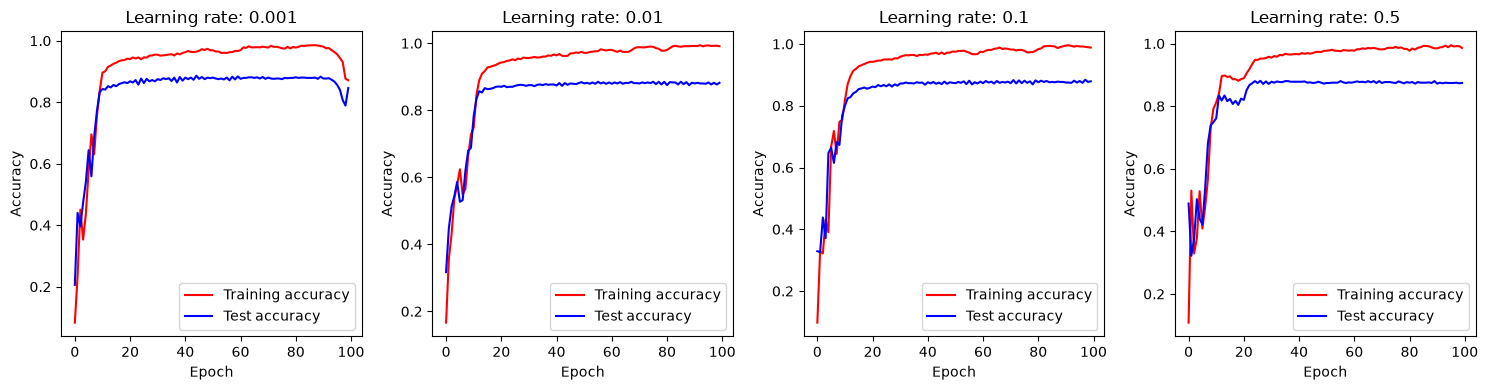

In [53]:
learning_rates = [0.001, 0.01, 0.1, 0.5]

fig, axes = plt.subplots(1, len(learning_rates), figsize = (15, 4))

for ax, lr in zip(axes, learning_rates):
    train_acc, test_acc = perceptron_alg(X_train, y_train, learning_rate = lr)

    ax.plot(train_acc, c = "red", label = "Training accuracy")
    ax.plot(test_acc, c = "blue", label = "Test accuracy")
    ax.set_title(f"Learning rate: {lr}")
    ax.set_xlabel("Epoch") # pog
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.tight_layout()
